# 03. 그래프 인과모델

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import graphviz as gr
from matplotlib import style
import seaborn as sns
from matplotlib import pyplot as plt

color=['0.3', '0.5', '0.7', '0.9']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

pd.set_option('display.max_rows', 6)

gr.set_default_format("png");

<br>

<hr>

<br>

 
## 03.01 인과관계

- **구조적 인과모델 (Structural Casual Models, SCM)** : 그래프의 인과 방정식으로 구성

<br>

#### 교차 판매 이메일 사례
- 처치 $T$ : 교차 판매 이메일
- 결과 $Y$ : 고객의 전환 여부
- **$T$는 무작위로 배정** $\rightarrow$ **처치 $T$는 잠재적 결과와 독립 $(Y_0, Y_1) \perp T$**
    
    $\rightarrow$ 연관관계를 인과관계로 설정
    
$$E[Y_1 - Y_0] = E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{ E[Y_0|T=1] - E[Y_0|T=0] \}}_{BIAS}$$

In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('./data/cross_sell_email.csv')
data.head()

,gender,cross_sell_email,age,conversion
0,0,short,15,0
1,1,short,27,0
2,1,long,17,0
3,1,long,34,0
4,1,no_email,14,0


**데이터만 보고 독립성 가정이 성립한다고 이야기 할 수 없음**
    
$\rightarrow$ 실험 대상에게 처치 배정에 관한 매커니즘 정보가 있어야 독립성 가정이 유지

$\rightarrow$ **교차 판매 이메일은 무작위로 고객에게 이메일이 발송되었음을 알기에, 독립성 가정이 성림**


<br>

###  01. 인과관계 시각화 

<br>

#### 교차 판매 이메일이 전환을 유도하고, 관측된 다른 변수인 나이와 성별도 전환의 원인이 될 때
- **측정하지 않은 기타 변수 (고객 소득, 사회적 배경, 나이 등) : $U$**
- **랜덤화 노드 : $T$**

<br>

> **인과관계는 되돌릴 수 없는 비가역적 가정이 존재 $\rightarrow$ 방향성 있는 비순환 그래프**
>
>> - 유향 비순환 그래프 (Directed Acyclic Graph, DAG)
        
<br>


In [4]:
import graphviz as gr

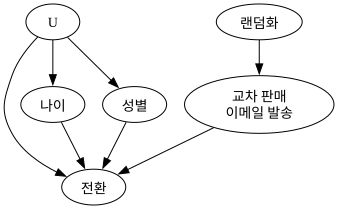

In [5]:
g_cross_sell = gr.Digraph()

g_cross_sell.edge("U", "전환")
g_cross_sell.edge("U", "나이")
g_cross_sell.edge("U", "성별")

g_cross_sell.edge("랜덤화", "교차 판매\n이메일 발송")
g_cross_sell.edge("교차 판매\n이메일 발송", "전환")
g_cross_sell.edge("나이", "전환")
g_cross_sell.edge("성별", "전환")

g_cross_sell

- 그래프의 각 노드는 확률변수
- **화살표나 엣지를 사용하여 한 변수가 다른 변수의 원인이 되는지 표시**
    
    $\rightarrow$ **그래프 모델에서는 전환의 원인은 이메일이 되고, $U$가 나이, 전환, 성별 등 변수의 원인을 나타냄**
 
<br>

#### **하지만 실제 데이터 적용에 있어, 존재하는 수백 개의 변수를 모두 그래프에 표현할 수는 없음**
    
- **실제로 전달하려는 일반적인 인과 이야기 (Casual Story)를 유지하면서, 노드를 묶어 획기적으로 그래프를 단순화**
    - 예) 그래프를 가지고 관측 가능한 변수를 X노드로 묶음
        
        두 변수 모두 $U$에 의해 발생하고 전환의 원인이 되므로, 이들을 결합해도 인과 이야기는 그대로 유지

    - **또한, 무작위로 배정되거나, 개입된 변수를 표현할 때는 들어오는 화살표를 모두 제거**

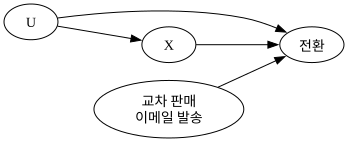

In [6]:
g_cross_sell = gr.Digraph(graph_attr={"rankdir": "LR"})

g_cross_sell.edge("U", "전환")
g_cross_sell.edge("U", "X")

g_cross_sell.edge("교차 판매\n이메일 발송", "전환")
g_cross_sell.edge("X", "전환")

g_cross_sell

<br>

#### DAG에서 가장 중요한 정보는 그래프 안에 없을 수 있음
- **즉, 한 변수에서 다른 변수로 연결되는 엣지가 없다는 것은, 두 변수 사이에 직접적인 인과관계가 없다고 가정한다는 의미**
    - 위의 그래프에서는 처치와 결과 모두에 대한 원인이 없다고 가정

<br>

### 02. 컨설턴트 영입 여부 결정하기
- 처치가 랜덤화 되지 않은 예시

> 컨설턴트 영입 여부를 고려하는 회사의 관리자
>
> **수익성이 매우 좋은 회사만 최고 수준의 컨설턴트를 고용할 수 있기 때문에, 그러한 컨설턴트를 고용했을 떄, 비즈니스를 개선할 수 있는 건지,**
>
> **그들의 존재가 좋은 회사의 실적과 상관관계가 있는 건지 확신할 수 없음**
>
> 회사마다 컨설턴트를 무작위로 배정받을 수 있다면, 최고 수준의 컨설턴트 고용이 얼마나 효과가 있는지 쉽게 답할 수 있지만, 그럴 수 없기에
>
> **연관관계로부터 인과관계를 해결해야 함**

<br>



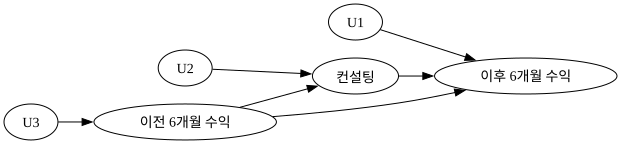

In [7]:
g_consultancy = gr.Digraph(graph_attr={"rankdir": "LR"})

g_consultancy.edge("U1", "이후 6개월 수익")
g_consultancy.edge("U2", "컨설팅")
g_consultancy.edge("U3", "이전 6개월 수익")

g_consultancy.edge("컨설팅", "이후 6개월 수익")

g_consultancy.edge("이전 6개월 수익", "컨설팅")
g_consultancy.edge("이전 6개월 수익", "이후 6개월 수익")

g_consultancy

- 측정할 수 없는 다른 요소가 변수의 원인이라는 사실을 표현 $\rightarrow$ 각 변수에 $U$ 노드를 추가
* 그래프는 일반적으로 확률변수를 나타내므로, 임의의 $U$가 모든 변수의 원인이 될 것으로 예상 가능
    
    하지만, 이러한 요소는 인과 이야기에 영향을 주지 않을 것이므로, 생략하는 것이 바람직

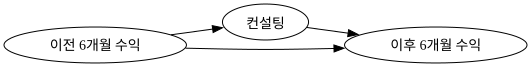

In [8]:
g_consultancy = gr.Digraph(graph_attr={"rankdir":"LR"})

g_consultancy.edge("컨설팅", "이후 6개월 수익")
g_consultancy.edge("이전 6개월 수익", "컨설팅")
g_consultancy.edge("이전 6개월 수익", "이후 6개월 수익")

g_consultancy

<br>

#### 위 그래프에 의한 일반적 결론
- **회사의 과거 실적이 최고 수준의 컨설턴트를 고용하게 됨**
    - 회사가 잘 된다면, 비싼 서비스 비용을 지불할 수 있지만, 실적이 좋지 않다면 지불할 여유가 없음
    
    $\rightarrow$ 과거 실적이 회사가 컨설턴트를 고용할 확률을 결정
    
    (이 관계가 반드시 결정적이지는 않음)
    
    **실적이 좋은 회사가 최고 수준의 컨설턴트를 고용할 가능성이 더 높다는 의미**
    
<br>

- 지난 6개월 동안 잘된 회사는 이후 6개월 동안에도 잘될 가능성이 매우 높음 (평균적이고 일반적인 결론)

<br>

#### 컨설팅은 실제로 회사의 실적을 높이는 원인이 되는가?
- **컨설팅과 미래 실적 사이의 연관성에는 두 가지 원인이 존재** : 해당 원인 중 하나는 인과관계, 다른 하나는 인과관계가 아님

<br>



<br>

<hr>

<br>

## 03.02 그래프 모델

<br>

### 01. 사슬 구조 (Chain)
- **$T$** : $M$의 원인
- **$M$** : $Y$의 원인
    - **중간 노드 (Intermediary node)는 $T$와 $Y$ 사이의 관계를 매개하는 매개자 (Mediator)**

<br>

- **이 그래프에서 인과관계는 화살표 방향으로만 흐르지만, 연관관계는 양방향**
    - 예) 인과추론을 알게 되면 문제 해결력이 향상, 문제 해결력이 향상되면 승진할 가능성이 높아진다는 가정
    
        - 인과적 지식은 문제 해결력을 향상 $\rightarrow$ 이는 결국 승진의 원인
        - 승진은 인과추론 지식에 달려 있다고 말할 수 있고, 인과추론 전문성이 높을수록 승진할 가능성이 높아짐
        - 또한 승진 가능성이 높을수록 인과 추론 지식이 많을 확률도 높아짐
        
        $\rightarrow$ **즉 승진이 인과추론 지식과 연관되는 것과 마찬가지로, 인과추론 지식도 승진과 연관**
        
        $\rightarrow$ **두 변수가 서로 연관되면, 두 변수는 독립이 아님**
        
$$T \not\perp Y\$$

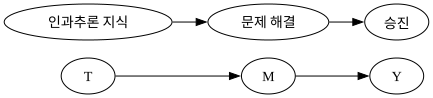

In [9]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})

g.edge("T", "M")
g.edge("M", "Y")
g.node("M", "M")


g.edge("인과추론 지식", "문제 해결")
g.edge("문제 해결", "승진")

g

<br>

#### 매개자 (매개변수)를 고정 
- **변수를 고정하는 것은 특정 변수의 값을 일정하게 유지하면서, 다른 변수들 간의 관계를 관측하는 것을 의미 ($M$에 대한 조건부)**
    
    해당 고정 변수의 영향을 **통제**하고, 다른 변수들 사이의 관계를 더 명확하게 이해
    
    $\rightarrow$ **종속성 (Dependence)이 차단 (Block)**
    
    $\rightarrow$ **$M$이 주어졋을 떄, $T$와 $Y$는 독립**
    
$$T \perp Y | M$$

- **$M$에 대한 조건부**
    - 예) **문제 해결력이 동일한 사람들을 살펴볼 때, 어떤 사람이 인과추론에 능숙한지 아는 것만으로는 승진 가능성에 대한 추가 정보를 얻을 수 없음**
    - 반대도 마찬가지 : 어떤 사람의 문제 해결력을 알게 되면, 직장 승진 상태를 알아도 인과추론 지식에 대한 추가 정보를 제공하지 않음
    
$$E[승진|문제 해결력, 인과추론 지식]=E[승진|문제 해결력]$$



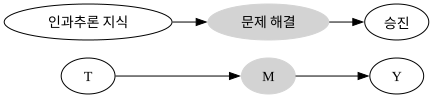

In [10]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})

g.edge("T", "M")
g.edge("M", "Y")
g.node("M", "M")
g.node("M", color="lightgrey", style="filled")


g.edge("인과추론 지식", "문제 해결")
g.edge("문제 해결", "승진")
g.node("문제 해결", color="lightgrey", style="filled")

g

<br>

- **매개변수 $M$을 조건부로 하면, $T$에서 $Y$로 흐르는 연관성은 차단**

$$T \perp Y \mid M$$


<br>

### 02 분기 (Fork)
- **분기 구조에는 공통 원인 (Common Cause)이 존재**
- 같은 변수가 그래프 아래쪽 다른 두 변수의 원인이 되며, 분기 구조에서 연관성은 화살표의 반대방향으로 흐름
    - 예) 톹계학 덕분에 인과추론과 머신러닝에 더 많은 지식
        - 인과추론을 잘 알아도 머신러닝에 도움이 되지 않으며, 그 반대도 마찬가지

            $\rightarrow$ 상대방의 통계지식수준을 모르더라도, 인과추론에 능숙하다면 통계를 잘 알 가능성이 높으며, 머신러닝도 잘 다룰 가능성이 높음

    - **분기 끝에 있는 변수들은 서로의 원인이 아니더라도, 같은 원인으로 발생하므로 함께 움직임**
- 인과추론에서 처치와 결과 사이에 공통 원인이 있을 때, 그 공통 원인은 **교란 요인 (Confounder)**


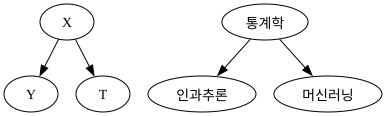

In [13]:
g = gr.Digraph()


g.edge("X", "Y")
g.edge("X", "T")
g.node("X", "X")

g.edge("통계학", "인과추론")
g.edge("통계학", "머신러닝")

g

<br>

- 만약 누군가의 통계지식 수준을 이미 알고 있다면?
    - 이 경우, 인과추론 능력이 머신러닝 능력에 대한 추가정보를 제공하지 않음

    **이미 누군가의 통계지식이 좋음/나쁨을 알고 있기 때문**

    $\rightarrow$ **좋은/나쁜 통계지식 수준이 주어졌다면, 인과추론 능력과 머신러닝 능력은 독립**

<br>

- **일반적으로 분기 구조에서 분기 구조에서 공통원인을 공유하는 두 변수 ($Y$, $T$)는 종속이지만**

    **공통원인이 주어지면, 독립**

$$
T \not \perp Y
$$

- 하지만 $X$가 주어진 경우에는

$$
T \perp Y | X
$$

<br>
 
### 03 충돌부 (Collider)
- **충돌부 구조는 두 노드가 하나의 자식 (Child)를공유하지만, 그들 사이에 직접적인 관계가 없는 경우**

    즉, 두 변수가 공통의 효과를 공유하며, 이 공통 효과는 두 개의 화살표가 충돌하므로 **충돌부**

<br>

- **충돌부 구조에서 두 부모 (Parent)노드는 서로 독립이지만, 공통 효과를 조건부로 두면 서로 종속**
    - 에) 승진하는 두 가지 방법
        - 통계를 잘 알거나 상사에게 잘 아부하는 사람은 승진
        - **승진을 조건부로 하지 않는다면 (승진 여부를 모른다면), 통계지식과 아부는 독립**
            
            **통계에 얼마나 능숙한지를 아는 것은, 상사에게 얼마나 아부를 잘 하는지에 대해 말해주지 않음**

        - **승진이 조건부라면 (승진 여부를 안다면)**

            통계를 잘 알지 못함 $\rightarrow$ 상사에게 아부를 잘함

            통계를 잘함 $\rightarrow$ 상사에게 아부를 잘하는지 알필요가 없음

            $\rightarrow$ **한 가지 원인이 이미 효과를 설명하므로, 다른 원인의 가능성이 더 낮아짐**

            $\rightarrow$ **다른 요인에 의해 설명되는 현상 (Explaining Away)**

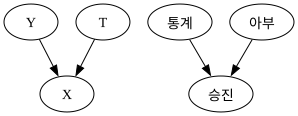

In [16]:
g = gr.Digraph()

g.edge("Y", "X")
g.edge("T", "X")

g.edge("통계", "승진")
g.edge("아부", "승진")

g

<br>

- **일반적으로 충돌부에 조건부를 두면, 연관 경로가 열리면서 부모 노드의 변수들은 종속**
    
    $X$가 주어진 경우

$$
T \not \perp Y | X
$$

- **조건부로 두지 않으면, 경로가 닫힌 상태로 유지 (독립)**

$$
T \perp Y
$$

<br>

- **충돌부에 대한 조건부 대신 (직접적이든 아니든) 충돌부의 효과에 조건부를 두어도 동일한 종속 경로 (Dependence Path)를 열 수 있음**
- **충돌부를 조건으로 두지 않고, 해당 충돌부의 원인을 조건부로 해도, 충돌부 원인들은 종속**
    - 예) **승진 ($X1$) $\rightarrow$ 연봉 ($X2$)이므로, 연봉상승을 조건부하는 것은 승진을 통제하는 효과와 동일**

        연봉 상승을 조건부하면, 승진 $X2$도 통제됨 $\rightarrow$ $Y$, $T$에 종속성이 생김

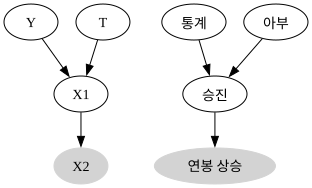

In [17]:
g = gr.Digraph()

g.edge("Y", "X1")
g.edge("T", "X1")
g.edge("X1", "X2")
g.node("X2", color="lightgrey", style="filled")

g.edge("통계", "승진")
g.edge("아부", "승진")
g.edge("승진", "연봉 상승")

g.node("연봉 상승", color="lightgrey", style="filled")

g

<br>

### 04. 연관관계 Flow
- 세 가지 구조 (사슬, 분기, 충돌부)를 알면 독립성과 연관성에 대한 흐름의 더 일반적인 규칙을 그래프로 도출 가능
- 경로는 다음과 같은 필요충분조건에 따라 차단될 수 있음
    1. **조건으로 주어진 비충돌부 구조가 포함됨**
    2. **조건부로 주어지지 않고 자식이 없는 충돌부가 포함**

<img src='https://raw.githubusercontent.com/CausalInferenceLab/Causal-Inference-with-Python/c4c824141fb4017fba05327ed0dae6f4d522bfde/causal-inference-for-the-brave-and-true/data/img/graph-flow.png'>

<br>

### 05. 그래프 쿼리


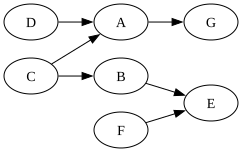

In [18]:
g = gr.Digraph(graph_attr={"rankdir": "LR"})
g.edge("C", "A")
g.edge("C", "B")
g.edge("D", "A")
g.edge("B", "E")
g.edge("F", "E")
g.edge("A", "G")

g

<br>

#### `nx.d_separated(G, x, y, z)`
- $G$ : 그래프 모델
- $x$, $y$ : 노드의 변수들
- $z$ : 조건부 변수

In [21]:
import networkx as nx

model = nx.DiGraph([
    ("C", "A"),
    ("C", "B"),
    ("D", "A"),
    ("B", "E"),
    ("F", "E"),
    ("A", "G"),
])

In [29]:
print("D와 C는 종속?")
print(not(nx.d_separated(model, {"D"}, {"C"}, {})), '\n')

print("A가 주어진 경우, D와 C는 종속?")
print(not(nx.d_separated(model, {"D"}, {"C"}, {"A"})), '\n')

print("G가 주어진 경우, D와 C는 종속?")
print(not(nx.d_separated(model, {"D"}, {"C"}, {"G"})), '\n')

print("G와 C는 종속?")
print(not(nx.d_separated(model, {"G"}, {"D"}, {})), '\n')

print("A가 주어진 경우, G와 D는 종속?")
print(not(nx.d_separated(model, {"G"}, {"D"}, {"A"})), '\n')

print("A와 B는 종속?")
print(not(nx.d_separated(model, {"A"}, {"B"}, {})), '\n')

print("C가 주어진 경우, A와 B는 종속?")
print(not(nx.d_separated(model, {"A"}, {"B"}, {"C"})), '\n')

print("G와 F는 종속?")
print(not(nx.d_separated(model, {"G"}, {"F"}, {})), '\n')

print("E가 주어진 경우, G와 F는 종속?")
print(not(nx.d_separated(model, {"G"}, {"F"}, {"E"})))

D와 C는 종속?
False 

A가 주어진 경우, D와 C는 종속?
True 

G가 주어진 경우, D와 C는 종속?
True 

G와 C는 종속?
True 

A가 주어진 경우, G와 D는 종속?
False 

A와 B는 종속?
True 

C가 주어진 경우, A와 B는 종속?
False 

G와 F는 종속?
False 

E가 주어진 경우, G와 F는 종속?
True


<br>

<hr>

<br>

## 03.03. 식별 재해석
- **무작위 배정이 없는 상황에서 인과관계를 찾기 어려운 이유 : 실험군과 대조군을 서로 비교할 수 없기 때문**
    - 예) 고가의 컨설턴트를 고용하는 회사는, 고용하지 않는 회사보다 일반적으로 과거 실적이 더 좋음 $\rightarrow$ 편향 

$$E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{ E[Y_0|T=1] - E[Y_0|T=0] \}}_{BIAS}$$


- **식별은 그래프에서 처치와 결과 간의 인과관계를 분리하는 과정**
    - 기본적으로 식별 단계에서는 바람직하지 않은 모든 연관성을 차단

<br>

#### 컨설팅 예시
- 처치와 결과 사이에는 두 가지 연관성 경로가 존재하지만, 그 중 하나만 인과관계

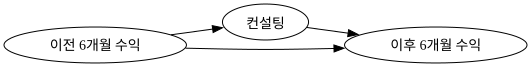

In [37]:
g_consultancy = gr.Digraph(graph_attr={"rankdir":"LR"})

g_consultancy.edge("컨설팅", "이후 6개월 수익")
g_consultancy.edge("이전 6개월 수익", "컨설팅")
g_consultancy.edge("이전 6개월 수익", "이후 6개월 수익")

g_consultancy

<br>

1. **인과 경로**

> **컨설팅** $\rightarrow$ **이후 6개월 수익**

<br>

2. **비인과 경로 (편향을 만드는 백도어, Backdoor)**

> **컨설팅** $\leftarrow$ **이전 6개월 수익** $\rightarrow$ **이후 6개월 수익**

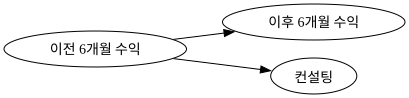

In [31]:
consultancy_sev = gr.Digraph(graph_attr={"rankdir": "LR"})
consultancy_sev.edge("이전 6개월 수익", "이후 6개월 수익")
consultancy_sev.edge("이전 6개월 수익", "컨설팅")

consultancy_sev

<br>

- **컨설팅의 효과가 아니라, 이전 수익이라는 교란요인 때문에 생긴 연관성**

    $\rightarrow$ **편향이 존재한다는 증거**

    $\rightarrow$ **교란 요인을 조건화하면, 백도어가 닫힘**

    - 예) **이전  6개월 수익 (교란요인이자 공통 원인)을 조건화 하는 것**

        - 과거에 실적이 비슷한 회사들의 그룹을 살펴보고, 해당 그룹 내에서 컨설턴트 여부에 대한 이후 수익을 비교
 

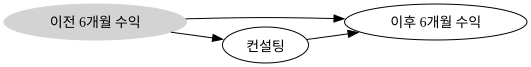

In [38]:
g_consultancy = gr.Digraph(graph_attr={"rankdir":"LR"})
g_consultancy.edge("이전 6개월 수익", "이후 6개월 수익")
g_consultancy.edge("이전 6개월 수익", "컨설팅")
g_consultancy.edge("컨설팅", "이후 6개월 수익")
g_consultancy.node("이전 6개월 수익", color="lightgrey", style="filled")

g_consultancy

<br>

<hr>

<br>

## 03.04. 조건부 독립성 가정과 보정 공식
- **조건부 독립성 가정 (Conditional Independence Assumption, CIA) : 공변량 $X$ 수준이 동일한 대상을 비교하면, 잠재적 결과는 평균적으로 같음을 의미**

    **즉, 공변량 $X$값이 동일한 대상을 보면 처치가 무작위로 배정된 것처럼 보임**

$$
(Y_0, Y_1) \perp T | X
$$

<br>

### 보정 공식 (Adjustment Formula, 조건부 원칙)
- **$X$를 조건부로 두거나 통제하면, 평균 처치효과는 실험군과 대조군 간 그룹 내 차이의 가중평균으로 식별**

    즉, 그래프에서 비인과 경로를 통한 연관성 흐름을 $X$에 조건부로 두어 차단하면 ATE와 같은 인과 추정량을 식별 가능

    $\rightarrow$ 교란요인을 보정하여 백도어를 차단화는 과정 = 백도어 보정

- 처치가 $X$그룹 내에서 무작위 배정이 된 것처럼 보인다면, $X$로 정의된 각 그룹 내에서는 실험군과 대조군을 비교하고,

    각 그룹의 크기를 가중치로 사용해서 해당 결과의 평균을 구하는 방법

    $\rightarrow$ **즉, 전체 ATE = 조건부 효과들의 가중평균**

$$
ATE = \sum \{(E[Y | T = 1, X = x] - E[Y|T=0, X =x]) P(X = x) \} \\
 = \sum^x_x \{E[Y | T=1, X=x]P(X = x) - E[Y | T = 0, X = x] P(X = x) \}
$$

<br>

#### 컨설팅 예시
- 교란요인 $X$를 조건화후, 각 조건 그룹의 비율 확인

| 이전 수익(X) | 컨설팅 효과 (T=1 vs T=0) |
| -------- | ------------------- |
| 낮음       | +2억                 |
| 중간       | +1억                 |
| 높음       | +0.1억               |

- 전체 기업 중 
    - 낮은 그룹 40%
    - 중간 그룹 40%
    - 높은 그룹 20%

$$
ATE = 0.4⋅2억+0.4⋅1억+0.2⋅0.1억
$$





<br>

<hr>

<br>

## 3.5 양수성 가정
- 보정 공식에서 처치와 결과 사이의 차이를 $X$에 따라 평균을 내므로, 

    **$X$의 모든 그룹에 실험군과 대조군의 실험 대상이 반드시 존재해야 함**

    $\rightarrow$ 그렇지 않다면, 그룹 간의 차이를 정의할 수 없음
- **처치의 조건부 확률은 반드시 양수이고 1미만 ($0 < P(T|X) < 1$)**

<br>

<hr>

## 03.06 식별 예제
- 수익이 낮은 기업 3개, 높은 회사 3개의 지난 6개월 데이터
- 수익성이 높은 기업들은 컨설턴트를 고용할 가능성이 높음
    - 수익이 높은 회사 3곳 중 2곳은 컨설턴트를 고용
    - 수익이 낮은 회사는 3곳 중 1곳만 컨설턴트를 고용

In [ ]:
df = pd.DataFrame(dict(
    profits_prev_6m=[1.0, 1.0, 1.0, 5.0, 5.0, 5.0],
    consultancy=[0, 0, 1, 0, 1, 1],
    profits_next_6m=[1, 1.1, 1.2, 5.5, 5.7, 5.7],
))

df

,profits_prev_6m,consultancy,profits_next_6m
0,1.0,0,1.0
1,1.0,0,1.1
2,1.0,1,1.2
3,5.0,0,5.5
4,5.0,1,5.7
5,5.0,1,5.7


- 컨설턴트를 고용한 회사와 고용하지 않은 회사의 수익 `profits_prev_6m`의 단순 비교 : 1.66백만 달러

    $\rightarrow$ 하지만 이는 컨설팅이 회사에 미치는 인과효과라고 할 수 없음

    $\rightarrow$ 과거 실적이 좋았던 회사들이 컨설턴트를 고용한 그룹에서 과대 대표 되었기 떄문

In [ ]:
(df.query("consultancy==1")["profits_next_6m"].mean() - df.query("consultancy==0")["profits_next_6m"].mean())

1.666666666666667

- 컨설턴트의 효과를 추정하기 위해서는 과거 실적이 비슷한 회사들을 비교

In [ ]:
avg_df = (df.groupby(['consultancy', 'profits_prev_6m'])['profits_next_6m'].mean())

avg_df.loc[1] - avg_df.loc[0]

profits_prev_6m
1.0    0.15
5.0    0.20
Name: profits_next_6m, dtype: float64

- 효과의 가중평균을 구할 때, 각 그룹의 크기를 가중치로 사용하면, 편향되지 않은 ATE를 추정값을 얻을 수 있음

    $\rightarrow$ 0.15 * 0.5 + 0.2 * 0.5 = 0.175

    - **단 조건부 독립성 가정 활용 필요 (과거 실적은 컨설턴트 고용과 미래 실적의 유일한 공통 원인이라고 가정)**


<br>

#### 앞문 (Frontdoor) 보정
- 처치가 매개변수에 미치는 영향이, 해당 매개변수가 결과에 미치는 영향을 식별할 수 있을 때,

    처치가 결과에 미치는 영향은 이 두 가지 효과를 결합한 것으로 식별

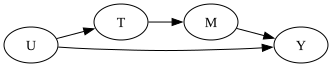

In [ ]:
g = gr.Digraph(graph_attr={"rankdir":"LR"})
g.edge("U", "T")
g.edge("U", "Y")
g.edge("T", "M")
g.edge("M", "Y")

g

<br>

<hr>